In [1]:
import glob
import os
import xarray as xa
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np
from scipy.interpolate import RectBivariateSpline
from scipy.stats import pearsonr
from scipy.ndimage import convolve

import cartopy.crs as ccrs
from cartopy.feature import LAND, COASTLINE
import cmocean.cm as ocm

from subprocess import call
import shutil


In [2]:
band_names = [
    'SI_12km_NH_18H_ASC',
    'SI_12km_NH_18V_ASC',
    'SI_12km_NH_23H_ASC',
    'SI_12km_NH_23V_ASC',
    'SI_12km_NH_36H_ASC',
    'SI_12km_NH_36V_ASC',
]
with xa.open_dataset('/data1/antonk/tmp/AMSR_U2_L3_SeaIce12km_B04_20230101.he5', group='HDFEOS/GRIDS/NpPolarGrid12km/Data Fields') as ds:
    bands = np.dstack([ds[band_name].to_numpy() for band_name in band_names])
    amsr2_sic = ds['SI_12km_NH_ICECON_ASC'].to_numpy()


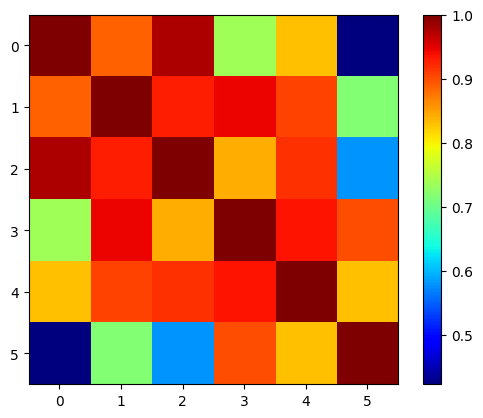

In [3]:
gpi = np.isfinite(bands[:,:,0]) * (amsr2_sic > 15) * (amsr2_sic <= 100)
bands_gpi = bands[gpi, :]
corr_coef = np.corrcoef(bands_gpi.T)
plt.imshow(corr_coef, cmap='jet')
plt.colorbar()
plt.show()

In [4]:

bands_min, band_max = np.percentile(bands_gpi, [0, 100], axis=0)
bands_min, band_max, bands.dtype

(array([114.80000171, 192.30000287, 127.4000019 , 199.40000297,
        135.40000202, 184.30000275]),
 array([252.90000377, 266.40000397, 257.90000384, 266.00000396,
        267.20000398, 270.30000403]),
 dtype('float64'))

/tmp/ipykernel_2309244/1938682113.py:6: RuntimeWarning: invalid value encountered in cast
  ), 0, 255).astype('uint8')


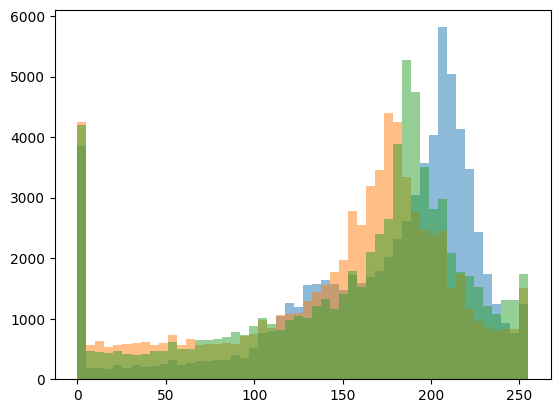

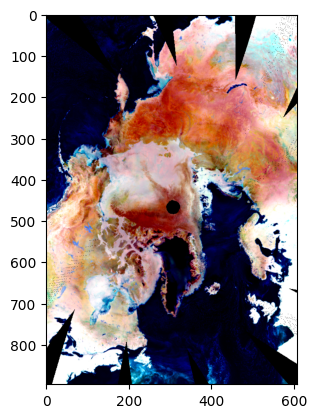

In [5]:
bands_min, band_max = np.percentile(bands_gpi, [5, 99], axis=0)
bands_sca = np.clip(
    255 * (
        (bands - bands_min[None][None]) /
        (band_max[None][None] - bands_min[None][None])
    ), 0, 255).astype('uint8')

_ =plt.hist(bands_sca[gpi, 0], 50, alpha=0.5)
_ =plt.hist(bands_sca[gpi, 3], 50, alpha=0.5)
_ =plt.hist(bands_sca[gpi, 5], 50, alpha=0.5)
plt.show()

plt.imshow(bands_sca[:,:,[0,3,5]])
plt.show()

/tmp/ipykernel_2309244/1590141487.py:3: RuntimeWarning: invalid value encountered in cast
  bands_sca = np.clip(255 * (0.6 + (bands - bands_avg[None][None]) / bands_std[None][None] / 4), 0, 255).astype('uint8')


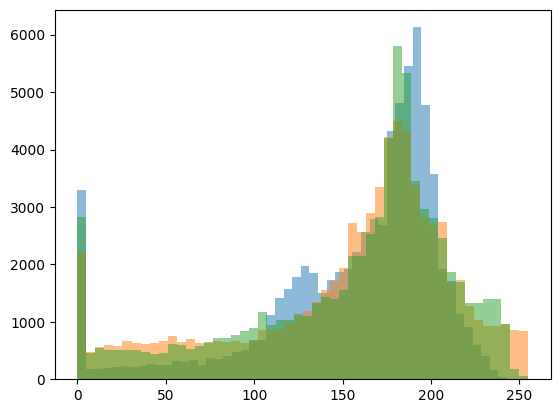

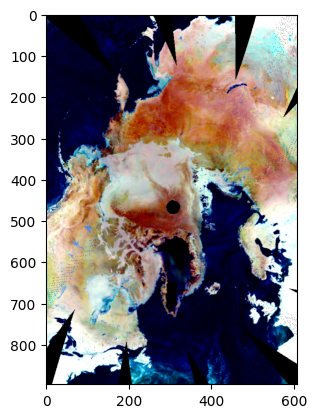

In [6]:
bands_avg = bands_gpi.mean(axis=0)
bands_std = bands_gpi.std(axis=0)
bands_sca = np.clip(255 * (0.6 + (bands - bands_avg[None][None]) / bands_std[None][None] / 4), 0, 255).astype('uint8')
_ =plt.hist(bands_sca[gpi, 0], 50, alpha=0.5)
_ =plt.hist(bands_sca[gpi, 3], 50, alpha=0.5)
_ =plt.hist(bands_sca[gpi, 5], 50, alpha=0.5)
plt.show()

plt.imshow(bands_sca[:,:,[0,3,5]])
plt.show()

In [7]:
with xa.open_dataset('/data1/antonk/tmp/AMSR_U2_L3_SeaIce12km_B04_20230101.he5', group='HDFEOS/GRIDS/NpPolarGrid12km') as ds:
    lon = ds.lon.to_numpy()
    lat = ds.lat.to_numpy()

In [8]:
titles = {
    'siconc': 'Concentration',
    'sithick': 'Thickness',
    'siconc_my': 'MYI concentration',
    'siage': 'Ice Age',
    'si_ridge_ratio': 'Ridged ice (roughness)',
    'sisnthick': 'Snow thickness',
}
ifile = '/data1/antonk/nextsim_reanalysis/2023/01/20230101_dm-nersc-MODEL-nextsimf-ARC-RAN-fv00.0.nc'
with xa.open_dataset(ifile) as ds:
    data = {name: ds[name][0].to_numpy() for name in titles}
    x = ds.x.to_numpy()
    y = ds.y.to_numpy()
data['mask'] = np.isnan(data['sithick'])
data['mask'][0] = True
titles['mask'] = 'Landmask'


In [9]:
proj = ccrs.NorthPolarStereo(true_scale_latitude=90, central_longitude=-45)
amsr_x, amsr_y, _ = proj.transform_points(ccrs.PlateCarree(), lon, lat).T
amsr_x, amsr_y = amsr_x.T, amsr_y.T

In [10]:
amsr_data = {}
for name in titles:
    data[name] = np.where(np.isnan(data[name]), 0, data[name])
    s = RectBivariateSpline(y, x, data[name])
    amsr_data[name] = s(amsr_y, amsr_x, grid=False)
    print(name)

siconc
sithick
siconc_my
siage
si_ridge_ratio
sisnthick
mask


In [11]:
for name in titles:
    if name != 'mask':
        amsr_data[name][amsr_data['mask'] > 0.1] = 0
        amsr_data[name][amsr_data[name] < 0.01] = 0

In [12]:
cube = np.dstack([bands, np.dstack([amsr_data[name] for name in titles])])
gpi = np.isfinite(cube[:,:,0]) * (cube[:, :, 12] < 0.5) * (amsr2_sic > 15) * (amsr2_sic <= 100)
cube_gpi = cube[gpi, :]

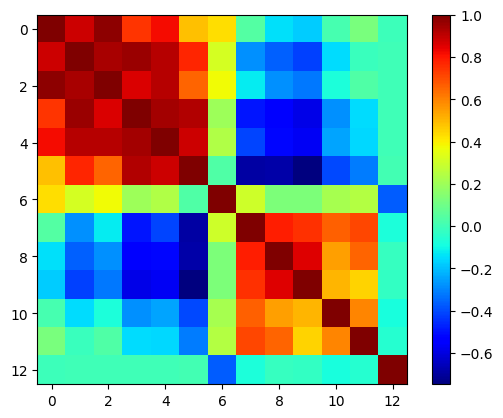

In [13]:
corr_coef_cube = np.corrcoef(cube_gpi.T)
plt.imshow(corr_coef_cube, cmap='jet')
plt.colorbar()
plt.show()

In [14]:
odir = '/data1/antonk/nextsim_reanalysis/2023/pngs'

A0 = np.vstack([cube_gpi[:, 6], cube_gpi[:, 7], np.ones_like(cube_gpi[:, 8])]).T
A1 = np.vstack([cube_gpi[:, 6], cube_gpi[:, 7], cube_gpi[:, 8], np.ones_like(cube_gpi[:, 8])]).T
A2 = np.vstack([cube_gpi[:, 6], cube_gpi[:, 7], cube_gpi[:, 8], cube_gpi[:, 9], np.ones_like(cube_gpi[:, 8])]).T
A3 = np.vstack([cube_gpi[:, 6], cube_gpi[:, 7], cube_gpi[:, 8], cube_gpi[:, 9], cube_gpi[:, 10], np.ones_like(cube_gpi[:, 8])]).T
A4 = np.vstack([cube_gpi[:, 6], cube_gpi[:, 7], cube_gpi[:, 8], cube_gpi[:, 9], cube_gpi[:, 10], cube_gpi[:, 11], np.ones_like(cube_gpi[:, 8])]).T
A5 = np.vstack([cube_gpi[:, 6], cube_gpi[:, 8], cube_gpi[:, 9], cube_gpi[:, 10], cube_gpi[:, 11], np.ones_like(cube_gpi[:, 8])]).T

bands_pred = {i:np.array(bands) for i in range(6)}

BB = {}

for model_no, A in enumerate([A0, A1, A2, A3, A4, A5]):
    for i, j in enumerate([0, 3, 5]):
        B = np.linalg.lstsq(A, cube_gpi[:, j])[0]
        BB[f'{model_no}_{j}'] = B
        Y = np.dot(A, B)
        bands_pred[model_no][gpi, j] = Y.flatten()
        r = pearsonr(Y, cube_gpi[:, j])[0]
        lims = np.percentile(cube_gpi[:, j], [1, 99])
        fig, axs = plt.subplots(1, 1, figsize=(5,5))
        axs.hist2d(cube_gpi[:, j], Y, 100, [lims, lims], cmin=1, norm=LogNorm())
        axs.plot(lims, lims, 'k-')
        axs.set_title(f'{r:0.3}')
        ofile = f'{odir}/scater_mod{model_no}_band{j}.png'
        print(ofile)
        plt.savefig(ofile, dpi=100, pad_inches=0.1, bbox_inches='tight')
        plt.close()

/tmp/ipykernel_2309244/1952585957.py:16: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  B = np.linalg.lstsq(A, cube_gpi[:, j])[0]


/data1/antonk/nextsim_reanalysis/2023/pngs/scater_mod0_band0.png
/data1/antonk/nextsim_reanalysis/2023/pngs/scater_mod0_band3.png
/data1/antonk/nextsim_reanalysis/2023/pngs/scater_mod0_band5.png
/data1/antonk/nextsim_reanalysis/2023/pngs/scater_mod1_band0.png
/data1/antonk/nextsim_reanalysis/2023/pngs/scater_mod1_band3.png
/data1/antonk/nextsim_reanalysis/2023/pngs/scater_mod1_band5.png
/data1/antonk/nextsim_reanalysis/2023/pngs/scater_mod2_band0.png
/data1/antonk/nextsim_reanalysis/2023/pngs/scater_mod2_band3.png
/data1/antonk/nextsim_reanalysis/2023/pngs/scater_mod2_band5.png
/data1/antonk/nextsim_reanalysis/2023/pngs/scater_mod3_band0.png
/data1/antonk/nextsim_reanalysis/2023/pngs/scater_mod3_band3.png
/data1/antonk/nextsim_reanalysis/2023/pngs/scater_mod3_band5.png
/data1/antonk/nextsim_reanalysis/2023/pngs/scater_mod4_band0.png
/data1/antonk/nextsim_reanalysis/2023/pngs/scater_mod4_band3.png
/data1/antonk/nextsim_reanalysis/2023/pngs/scater_mod4_band5.png
/data1/antonk/nextsim_rea

0 15.416060244522887
3 7.832560949911199
5 8.824752337170755


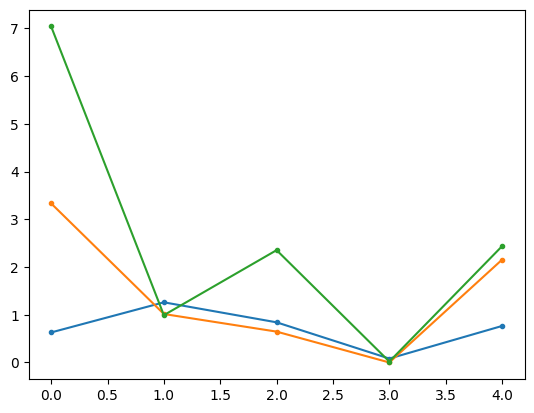

In [15]:
for i, j in enumerate([0, 3, 5]):
    B = BB[f'4_{j}']
    Y_ref = np.dot(A4, B)
    rmse_ref = ((Y_ref - cube_gpi[:, j])**2).mean()**0.5

    print(j, rmse_ref)
    r_rnds = []
    for var_num in range(1, 6):
        A = np.array(A4)
        A[:,var_num] = np.random.permutation(A[:,var_num])
        Y_rnd = np.dot(A, B)
        rmse_rnd = ((Y_rnd - cube_gpi[:, j])**2).mean()**0.5
        r_rnds.append(rmse_rnd - rmse_ref)
    plt.plot(r_rnds, '.-')

In [16]:
model_titles = [
    'SIC,SIT',
    'SIC,SIT,MYI',
    'SIC,SIT,MYI,SIA',
    'SIC,SIT,MYI,SIA,SIR',
    'SIC,SIT,MYI,SIA,SIR,SNT',
    'SIC,MYI,SIA,SIR,SNT'
    ]
for model_no in range(6):
    bands_pred_sca = np.clip(255 * (0.6 + (bands_pred[model_no] - bands_avg[None][None]) / bands_std[None][None] / 4), 0, 255).astype('uint8')
    fig, axs = plt.subplots(1, 3, figsize=(15, 6))
    axs[0].imshow(bands_sca[:,:,[0,3,5]], extent=[amsr_x.min(), amsr_x.max(), amsr_y.min(), amsr_y.max()])
    axs[1].imshow(bands_pred_sca[:,:,[0,3,5]], extent=[amsr_x.min(), amsr_x.max(), amsr_y.min(), amsr_y.max()])
    axs[2].imshow(bands_pred[model_no][:,:,0] - cube[:,:,0], extent=[amsr_x.min(), amsr_x.max(), amsr_y.min(), amsr_y.max()], clim=[-70, 70], cmap='coolwarm')
    axs[0].set_title('AMSR2')
    axs[1].set_title(model_titles[model_no])
    for ax in axs:
        ax.set_xlim([-2.5e6, 1.5e6])
        ax.set_ylim([-2e6, 2e6])
    ofile = f'{odir}/amsr2_maps_mo{model_no}.png'
    plt.savefig(ofile, dpi=150, bbox_inches='tight', pad_inches=0.1)
    #plt.show()
    print(ofile)
    plt.close()


/tmp/ipykernel_2309244/2281142241.py:10: RuntimeWarning: invalid value encountered in cast
  bands_pred_sca = np.clip(255 * (0.6 + (bands_pred[model_no] - bands_avg[None][None]) / bands_std[None][None] / 4), 0, 255).astype('uint8')


/data1/antonk/nextsim_reanalysis/2023/pngs/amsr2_maps_mo0.png
/data1/antonk/nextsim_reanalysis/2023/pngs/amsr2_maps_mo1.png
/data1/antonk/nextsim_reanalysis/2023/pngs/amsr2_maps_mo2.png
/data1/antonk/nextsim_reanalysis/2023/pngs/amsr2_maps_mo3.png
/data1/antonk/nextsim_reanalysis/2023/pngs/amsr2_maps_mo4.png
/data1/antonk/nextsim_reanalysis/2023/pngs/amsr2_maps_mo5.png


In [24]:
odir = '/data1/antonk/nextsim_reanalysis/2023/pngs'

titles = {
    'siconc': 'Concentration',
    'sithick': 'Thickness',
    'siconc_my': 'MYI concentration',
    'siage': 'Ice Age',
    'si_ridge_ratio': 'Ridged ice (roughness)',
    'sisnthick': 'Snow thickness',
}

ifiles = sorted(glob.glob('/data1/antonk/nextsim_reanalysis/2023/0[1-4]/*.nc'))
len(ifiles)

120

In [25]:
for ifile in ifiles:
    datestr = os.path.basename(ifile).split('_')[0]
    ofile = f'{odir}/rgb_snt_{datestr}.npz'
    if os.path.exists(ofile):
        continue

    try:
        with xa.open_dataset(ifile) as ds:
            data = {name: ds[name][0].to_numpy() for name in titles}
            x = ds.x.to_numpy()
            y = ds.y.to_numpy()
    except:
        continue

    A4_full = np.vstack([
        data['siconc'].flatten(),
        data['sithick'].flatten(),
        data['siconc_my'].flatten(),
        data['siage'].flatten(),
        data['si_ridge_ratio'].flatten(),
        data['sisnthick'].flatten(),
        np.ones(data['siconc'].size)
    ]).T

    Y_pred = []
    for i, j in enumerate([0, 3, 5]):
        y_pred = np.dot(A4_full, BB[f'4_{j}']).reshape(data['siconc'].shape)
        y_pred_sca = np.clip(255 * (0.6 + (y_pred - bands_avg[j]) / bands_std[j] / 4), 0, 255).astype('uint8')
        Y_pred.append(y_pred_sca)
    Y_pred = np.dstack(Y_pred)

    cimr_weights = np.array([[0.5,0.5],[0,0]])
    #amsr_weights = np.ones((9,6)) / 9 / 6

    Y_pred_cimr = np.dstack([convolve(Y_pred[:,:,i], cimr_weights) for i in range(3)])
    #Y_pred_amsr = np.dstack([convolve(Y_pred[:,:,i], amsr_weights) for i in range(3)])
    np.savez(ofile, Y_pred_cimr=Y_pred_cimr)#, Y_pred_amsr=Y_pred_amsr)



/tmp/ipykernel_2309244/3652904309.py:28: RuntimeWarning: invalid value encountered in cast
  y_pred_sca = np.clip(255 * (0.6 + (y_pred - bands_avg[j]) / bands_std[j] / 4), 0, 255).astype('uint8')
/tmp/ipykernel_2309244/3652904309.py:28: RuntimeWarning: invalid value encountered in cast
  y_pred_sca = np.clip(255 * (0.6 + (y_pred - bands_avg[j]) / bands_std[j] / 4), 0, 255).astype('uint8')
/tmp/ipykernel_2309244/3652904309.py:28: RuntimeWarning: invalid value encountered in cast
  y_pred_sca = np.clip(255 * (0.6 + (y_pred - bands_avg[j]) / bands_std[j] / 4), 0, 255).astype('uint8')
/tmp/ipykernel_2309244/3652904309.py:28: RuntimeWarning: invalid value encountered in cast
  y_pred_sca = np.clip(255 * (0.6 + (y_pred - bands_avg[j]) / bands_std[j] / 4), 0, 255).astype('uint8')
/tmp/ipykernel_2309244/3652904309.py:28: RuntimeWarning: invalid value encountered in cast
  y_pred_sca = np.clip(255 * (0.6 + (y_pred - bands_avg[j]) / bands_std[j] / 4), 0, 255).astype('uint8')
/tmp/ipykernel_23092

In [26]:
ifiles = sorted(glob.glob(
    '/data1/antonk/nextsim_reanalysis/2023/pngs/rgb_snt*npz'
))

In [28]:
for i, ifile in enumerate(ifiles):
    ofile = ifile.replace('.npz', '.png')
    #if os.path.exists(ofile):
    #    continue
    try:
        with np.load(ifile, allow_pickle=True) as ds:
            Y_pred_cimr = ds['Y_pred_cimr']
            #Y_pred_amsr = ds['Y_pred_amsr']
    except:
        continue

    fig, ax = plt.subplots(1, 1, figsize=(9,6), sharey=True, subplot_kw={'projection': proj},)
    ax.imshow(
        Y_pred_cimr,
        extent=[x[0], x[-1], y[0], y[-1]],
        origin='lower',
        zorder = 0,
    )
    ax.set_xlim([-2.0e6, 1.5e6])
    ax.set_ylim([-1.5e6, 1.5e6])
    ax.add_feature(LAND, zorder=1)
    ax.add_feature(COASTLINE, zorder=2)
    plt.tight_layout()
    plt.savefig(ofile, bbox_inches='tight', pad_inches=0.1, dpi=200)
    plt.close()
    print(ofile)


/data1/antonk/nextsim_reanalysis/2023/pngs/rgb_snt_20230101.png
/data1/antonk/nextsim_reanalysis/2023/pngs/rgb_snt_20230102.png
/data1/antonk/nextsim_reanalysis/2023/pngs/rgb_snt_20230103.png
/data1/antonk/nextsim_reanalysis/2023/pngs/rgb_snt_20230104.png
/data1/antonk/nextsim_reanalysis/2023/pngs/rgb_snt_20230105.png
/data1/antonk/nextsim_reanalysis/2023/pngs/rgb_snt_20230106.png
/data1/antonk/nextsim_reanalysis/2023/pngs/rgb_snt_20230107.png
/data1/antonk/nextsim_reanalysis/2023/pngs/rgb_snt_20230108.png
/data1/antonk/nextsim_reanalysis/2023/pngs/rgb_snt_20230109.png
/data1/antonk/nextsim_reanalysis/2023/pngs/rgb_snt_20230110.png
/data1/antonk/nextsim_reanalysis/2023/pngs/rgb_snt_20230111.png
/data1/antonk/nextsim_reanalysis/2023/pngs/rgb_snt_20230112.png
/data1/antonk/nextsim_reanalysis/2023/pngs/rgb_snt_20230113.png
/data1/antonk/nextsim_reanalysis/2023/pngs/rgb_snt_20230114.png
/data1/antonk/nextsim_reanalysis/2023/pngs/rgb_snt_20230115.png
/data1/antonk/nextsim_reanalysis/2023/pn

In [29]:
name = 'rgb_snt'
png_files = sorted(glob.glob(f'{odir}/{name}*png'))
frame_files = sorted(glob.glob(f'{odir}/frames/*png'))
[os.remove(f) for f in frame_files]
for i, png_file in enumerate(png_files):
    frame_name = f'{odir}/frames/frame_{i:05}.png'
    shutil.copy(png_file, frame_name)


In [30]:

cmd = f"ffmpeg -y -r 6 -i {odir}/frames/frame_%05d.png -b 10M -r 25 -c:v libx264 -pix_fmt yuv420p ~/{name}.mov"
print(cmd)
call(cmd, shell=True)

ffmpeg -y -r 6 -i /data1/antonk/nextsim_reanalysis/2023/pngs/frames/frame_%05d.png -b 10M -r 25 -c:v libx264 -pix_fmt yuv420p ~/rgb_snt.mov


ffmpeg version 4.2.2 Copyright (c) 2000-2019 the FFmpeg developers
  built with gcc 7.3.0 (crosstool-NG 1.23.0.449-a04d0)
  configuration: --prefix=/tmp/build/80754af9/ffmpeg_1587154242452/_h_env_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placeho --cc=/tmp/build/80754af9/ffmpeg_1587154242452/_build_env/bin/x86_64-conda_cos6-linux-gnu-cc --disable-doc --enable-avresample --enable-gmp --enable-hardcoded-tables --enable-libfreetype --enable-libvpx --enable-pthreads --enable-libopus --enable-postproc --enable-pic --enable-pthreads --enable-shared --enable-static --enable-version3 --enable-zlib --enable-libmp3lame --disable-nonfree --enable-gpl --enable-gnutls --disable-openssl --enable-libopenh264 --enable-libx264
  libavutil      56. 31.100 / 56. 31.100
  libavcodec     58. 54.100 / 58. 54.100
  libavformat    58. 29.100 / 58. 29.100


0